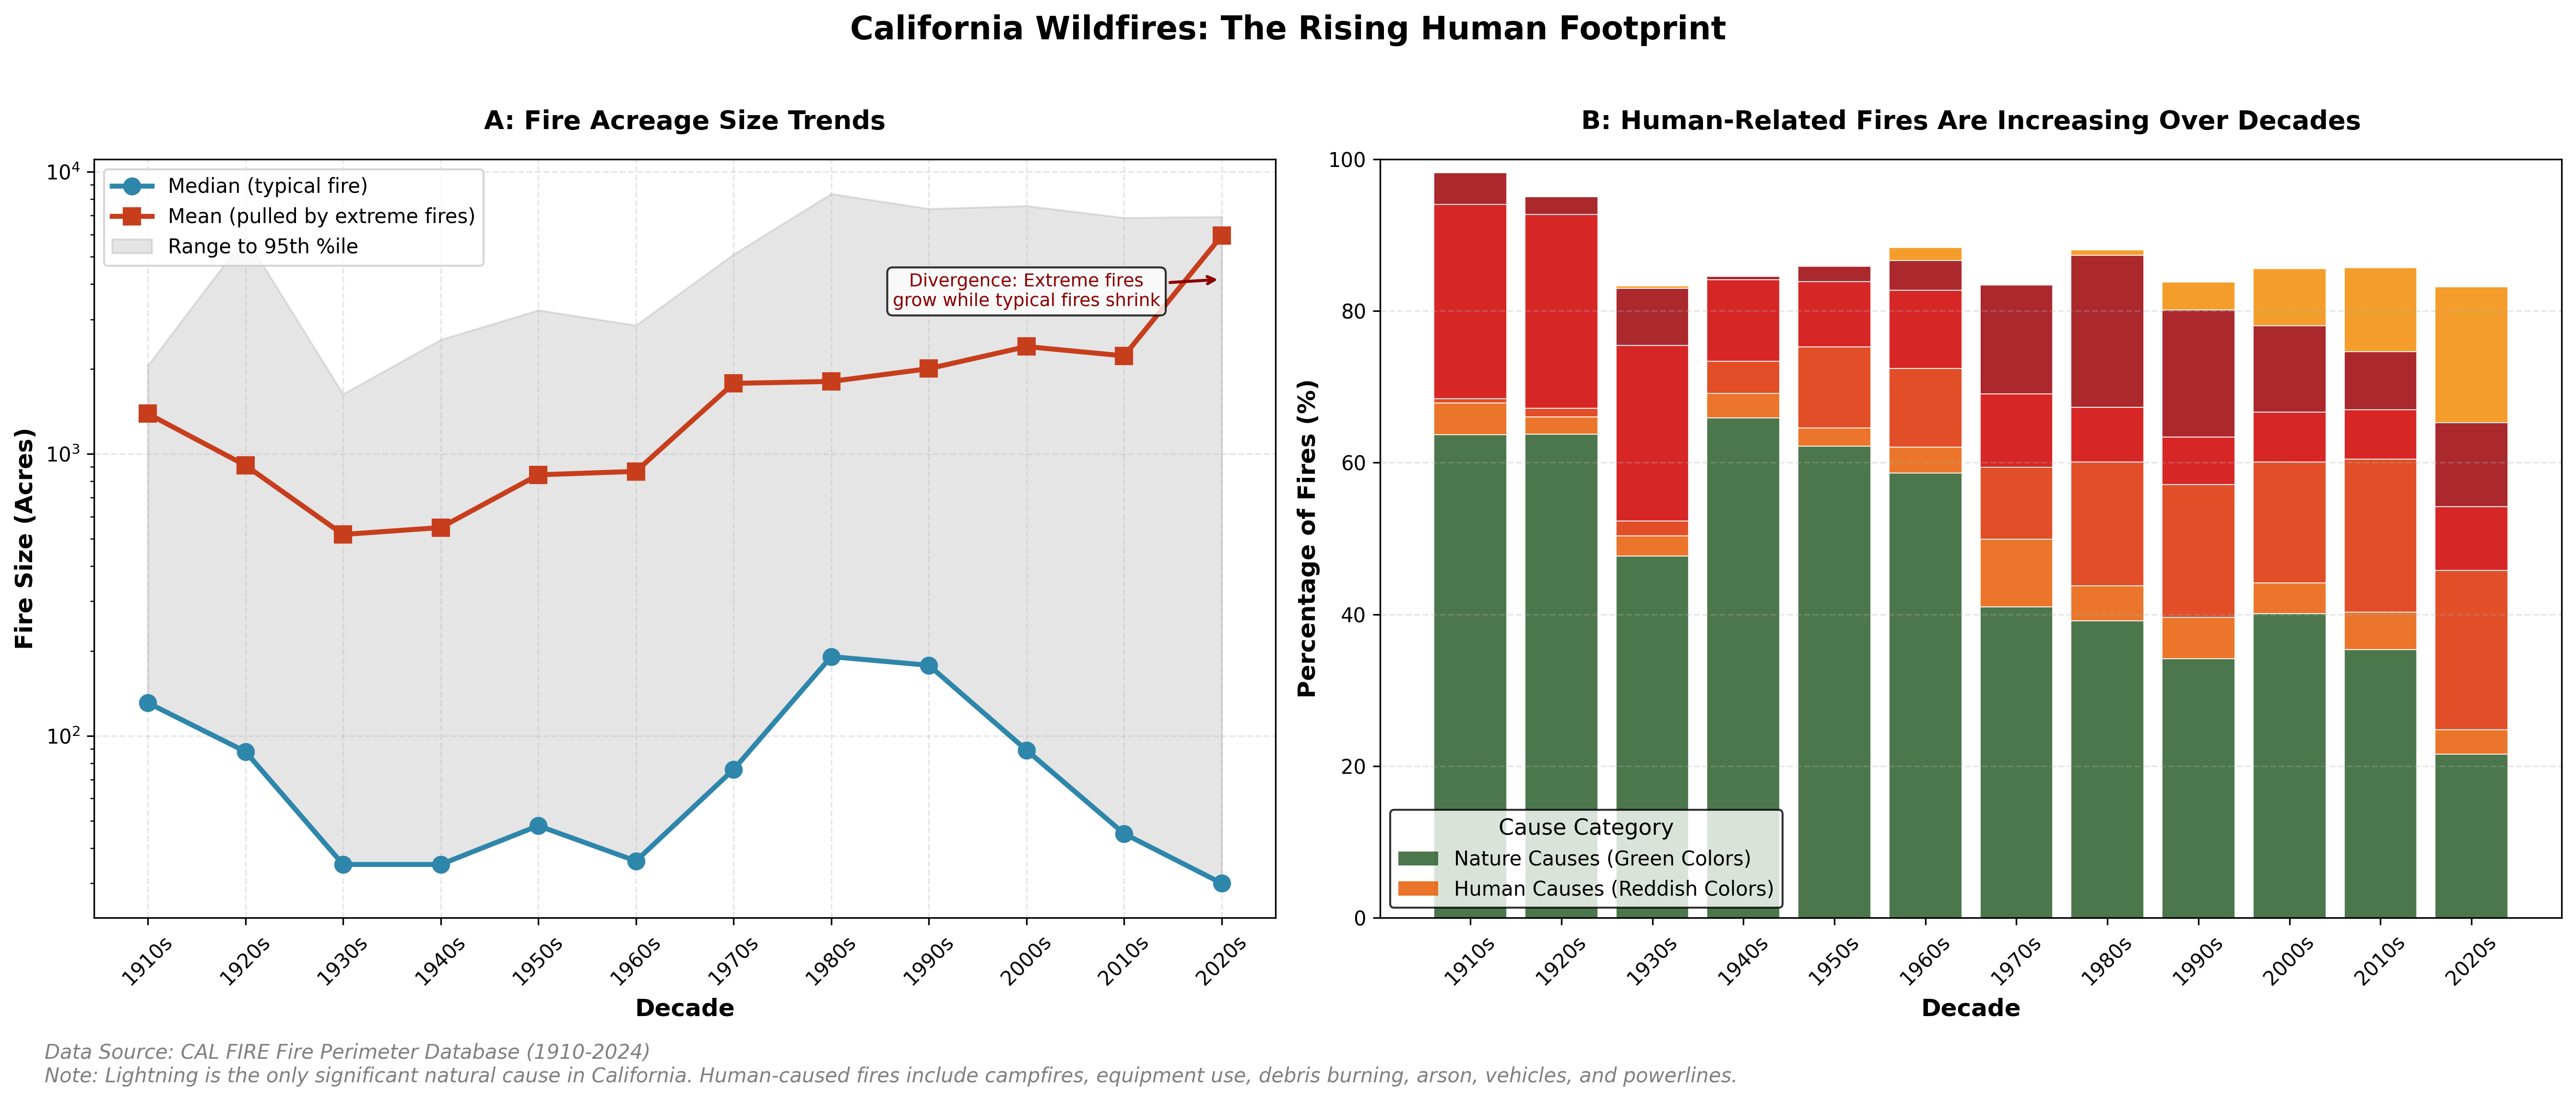

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load data
fire = pd.read_csv('https://gis.data.cnra.ca.gov/api/download/v1/items/c3c10388e3b24cec8a954ba10458039d/csv?layers=0')

# Cause mapping
cause_mapping = {1: "Lightning", 2: "Equipment Use", 3: "Smoking", 4: "Campfire",
                 5: "Debris", 6: "Railroad", 7: "Arson", 8: "Playing with fire",
                 9: "Miscellaneous", 10: "Vehicle", 11: "Powerline", 
                 12: "Firefighter Training", 13: "Non-Firefighter Training",
                 14: "Unknown/Unidentified", 15: "Structure", 16: "Aircraft",
                 17: "Volcanic", 18: "Escaped Prescribed Burn", 
                 19: "Illegal Alien Campfire"}

# Create new column with descriptive names
fire['Cause_Name'] = fire['Cause'].map(cause_mapping)

# Filter for positive acreage and remove unknowns
acres_col = 'GIS Calculated Acres' if 'GIS Calculated Acres' in fire.columns else 'Calculated_Acres'
fire_clean = fire[(fire[acres_col] > 0) & (~fire['Cause_Name'].isin(['Unknown/Unidentified', 'Miscellaneous']))].copy()

# Create decade categories
fire_clean['Decade'] = (fire_clean['Year'] // 10) * 10
fire_clean['Decade_Label'] = fire_clean['Decade'].astype(int).astype(str) + 's'

# Calculate statistics by decade (only include decades with data)
decade_stats = fire_clean.groupby('Decade_Label').agg({acres_col: ['median', 'mean', 'count', lambda x: x.quantile(0.95)]}).round(0)
decade_stats.columns = ['Median', 'Mean', 'Count', '95th_Percentile']
decade_stats = decade_stats.reset_index()

# Convert to numeric for plotting and sort
decade_stats['Decade_Num'] = decade_stats['Decade_Label'].str.extract('(\d+)').astype(float)
decade_stats = decade_stats.sort_values('Decade_Num')

# Calculate causes by decade
cause_by_decade = fire_clean.groupby(['Decade_Label', 'Cause_Name']).size().unstack(fill_value=0)
cause_by_decade_pct = cause_by_decade.div(cause_by_decade.sum(axis=1), axis=0) * 100

# Categorize causes as Nature or Human
nature_causes = ['Lightning', 'Volcanic']
human_causes = [cause for cause in cause_by_decade_pct.columns if cause not in nature_causes]

# Select top causes in the data
available_causes = cause_by_decade_pct.columns
preferred_causes = ['Lightning', 'Campfire', 'Equipment Use', 'Debris', 'Arson', 'Vehicle']
top_causes = [cause for cause in preferred_causes if cause in available_causes]

# Color scheme: greens for nature, warm colors for human
color_scheme = {'Lightning': '#2C5F2D', 'Volcanic': '#4C9A2A', 'Campfire': '#E85D04', 'Equipment Use': '#DC2F02', 'Debris': '#D00000', 'Arson': '#9D0208', 
                'Vehicle': '#F48C06', 'Powerline': '#E85D04', 'Smoking': '#FAA307', 'Railroad': '#FFBA08'}

# Two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=300)

# PLOT 1: Fire Severity Trends 
ax1.plot(decade_stats['Decade_Num'], decade_stats['Median'], 'o-', linewidth=2.5, markersize=8, color='#2E86AB', label='Median (typical fire)', zorder=3)
ax1.plot(decade_stats['Decade_Num'], decade_stats['Mean'], 's-', linewidth=2.5, markersize=8, color='#C73E1D', label='Mean (pulled by extreme fires)', zorder=3)
ax1.fill_between(decade_stats['Decade_Num'], decade_stats['Median'], decade_stats['95th_Percentile'], alpha=0.2, color='gray', label='Range to 95th %ile', zorder=1)
ax1.set_yscale('log')
ax1.set_ylabel('Fire Size (Acres)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax1.set_title('A: Fire Acreage Size Trends', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--', zorder=0)
ax1.legend(loc='upper left', frameon=True, fontsize=10)

# Set x-ticks with decade labels
ax1.set_xticks(decade_stats['Decade_Num'])
ax1.set_xticklabels(decade_stats['Decade_Label'], rotation=45)

# Add annotation for the divergence (if enough data points)
if len(decade_stats) >= 2:
    ax1.annotate('Divergence: Extreme fires\ngrow while typical fires shrink', 
                 xy=(decade_stats['Decade_Num'].iloc[-1], decade_stats['Mean'].iloc[-1] * 0.7), 
                 xytext=(decade_stats['Decade_Num'].iloc[-3], decade_stats['Mean'].iloc[-2] * 1.5),
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
                 fontsize=9, ha='center', color='darkred',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# PLOT 2: Cause Composition (Right) - Color-coded by Nature vs Human
# Reindex to match the sorted decades
cause_by_decade_top = cause_by_decade_pct[top_causes].reindex(decade_stats['Decade_Label'])

# Create stacked bar plot with custom colors
x_positions = np.arange(len(cause_by_decade_top.index))
bottom = np.zeros(len(cause_by_decade_top.index))

# Plot each cause
for cause in top_causes:
    values = cause_by_decade_top[cause].values
    # Fill NaN values with 0
    values = np.nan_to_num(values)
    color = color_scheme.get(cause, '#CCCCCC')
    
    ax2.bar(x_positions, values, bottom=bottom, label=cause, 
            color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += values

ax2.set_ylabel('Percentage of Fires (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax2.set_title('B: Human-Related Fires Are Increasing Over Decades', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, 100)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(cause_by_decade_top.index, rotation=45)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--', zorder=0)

# Define legend entries
nature_patch = Patch(facecolor='#2C5F2D', alpha=0.85, label='Nature Causes (Green Colors)')
human_patch = Patch(facecolor='#E85D04', alpha=0.85, label='Human Causes (Reddish Colors)')

# Add the legend to the plot
ax2.legend(handles=[nature_patch, human_patch], 
           loc='lower left', 
           fontsize=10, 
           title='Cause Category',
           title_fontsize=11,
           frameon=True,
           edgecolor='black')

plt.suptitle('California Wildfires: The Rising Human Footprint', fontsize=16, fontweight='bold', y=1.02)

plt.figtext(0.02, -0.04, 
            f"Data Source: CAL FIRE Fire Perimeter Database ({fire_clean['Year'].min():.0f}-{fire_clean['Year'].max():.0f})\n"
            "Note: Lightning is the only significant natural cause in California. Human-caused fires include campfires, equipment use, "
            "debris burning, arson, vehicles, and powerlines.",
            fontsize=10, ha='left', style='italic', color='gray')

plt.tight_layout()
plt.show()

# Save image
fig.savefig('california_wildfires_trends.png', dpi=300, bbox_inches='tight')